# Notebook 04 — Statistical Analysis

**Project:** Why Startups Fail — VC Investment Pattern Analysis  
**Team:** Section C, Group 17  

---
**Objective:** Apply rigorous statistical methods — hypothesis testing, correlation analysis, regression, and segmentation — to identify statistically significant predictors of startup failure. All results are reported with p-values, effect sizes, and business interpretations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, pointbiserialr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('/content/startups_cleaned.csv', low_memory=False)
print(f'Loaded: {df.shape[0]:,} rows')
print('Statistical analysis initialized.')

Loaded: 28,534 rows
Statistical analysis initialized.


In [3]:
contingency = pd.crosstab(df['status'], df['reached_series_a'])
print('Contingency Table — Status vs. Reached Series A:')
print(contingency.to_string())

chi2, p_value, dof, expected = chi2_contingency(contingency)

# Cramér's V for effect size
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f'\nChi-Square Statistic : {chi2:.4f}')
print(f'Degrees of Freedom   : {dof}')
print(f'P-value              : {p_value:.6f}')
print(f"Cramér's V           : {cramers_v:.4f}")
print()
if p_value < 0.05:
    print('RESULT: REJECT H₀ — Statistically significant association (p < 0.05)')
    print(f'Effect size (Cramér\'s V = {cramers_v:.3f}): {"Small" if cramers_v < 0.3 else "Medium" if cramers_v < 0.5 else "Large"}')
else:
    print('RESULT: FAIL TO REJECT H₀ — No significant association found')

print()
print('BUSINESS INTERPRETATION:')
print('Reaching Series A is not random — it is strongly associated with startup survival.')
print('Investors at Series A stage act as a quality filter, dramatically reducing future closure probability.')

Contingency Table — Status vs. Reached Series A:
reached_series_a      0     1
status                       
acquired            888  1502
closed             1010   440
operating         17052  7642

Chi-Square Statistic : 1001.1969
Degrees of Freedom   : 2
P-value              : 0.000000
Cramér's V           : 0.1873

RESULT: REJECT H₀ — Statistically significant association (p < 0.05)
Effect size (Cramér's V = 0.187): Small

BUSINESS INTERPRETATION:
Reaching Series A is not random — it is strongly associated with startup survival.
Investors at Series A stage act as a quality filter, dramatically reducing future closure probability.


Closed startups    — n=1,450, median=$863,880
Operating startups — n=24,694, median=$1,800,000

Mann-Whitney U     : 14875628.50
P-value (one-sided): 0.00000000
Effect size r      : 0.0671

RESULT: REJECT H₀ — Closed startups receive significantly LESS funding (p < 0.05)

BUSINESS INTERPRETATION:
Underfunding is a statistically significant predictor of startup failure.
VC firms should evaluate minimum viable runway before seed-stage investment.


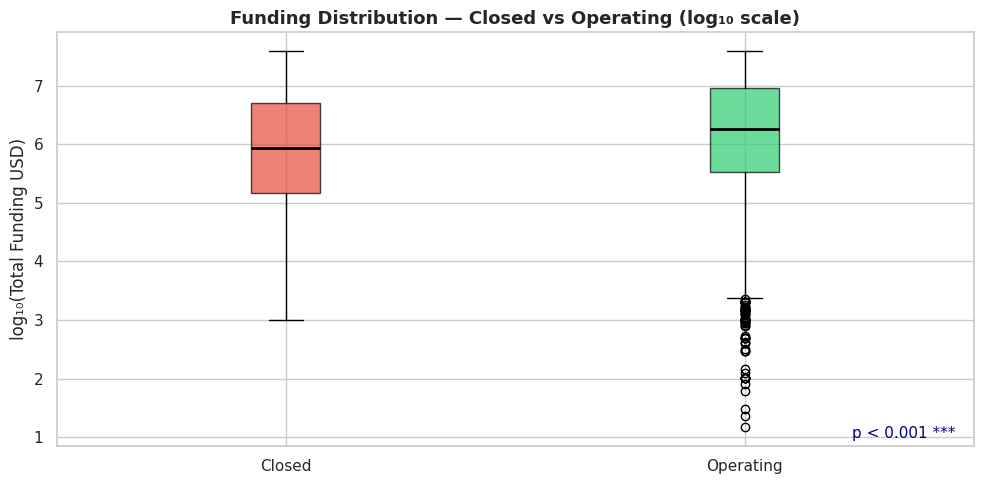

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, norm
from google.colab import files

# -----------------------
# DATA PREP
# -----------------------
closed_funding = df[
    (df['status'] == 'closed') &
    (df['funding_total_usd'] > 0)
]['funding_total_usd'].dropna()

operating_funding = df[
    (df['status'] == 'operating') &
    (df['funding_total_usd'] > 0)
]['funding_total_usd'].dropna()

print(f'Closed startups    — n={len(closed_funding):,}, median=${np.median(closed_funding):,.0f}')
print(f'Operating startups — n={len(operating_funding):,}, median=${np.median(operating_funding):,.0f}')

# -----------------------
# STAT TEST
# -----------------------
u_stat, p_val = mannwhitneyu(
    closed_funding,
    operating_funding,
    alternative='less'
)

# Effect size
z = norm.ppf(p_val)
r_effect = abs(z) / np.sqrt(len(closed_funding) + len(operating_funding))

print(f'\nMann-Whitney U     : {u_stat:.2f}')
print(f'P-value (one-sided): {p_val:.8f}')
print(f'Effect size r      : {r_effect:.4f}')
print()

if p_val < 0.05:
    print('RESULT: REJECT H₀ — Closed startups receive significantly LESS funding (p < 0.05)')
else:
    print('RESULT: FAIL TO REJECT H₀')

print('\nBUSINESS INTERPRETATION:')
print('Underfunding is a statistically significant predictor of startup failure.')
print('VC firms should evaluate minimum viable runway before seed-stage investment.')

# -----------------------
# PLOT (BOXPLOT)
# -----------------------
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = [
    np.log10(closed_funding + 1),
    np.log10(operating_funding + 1)
]

bp = ax.boxplot(
    plot_data,
    patch_artist=True,
    labels=['Closed', 'Operating'],
    medianprops={'color': 'black', 'linewidth': 2}
)

bp['boxes'][0].set_facecolor('#E74C3C')
bp['boxes'][1].set_facecolor('#2ECC71')

for patch in bp['boxes']:
    patch.set_alpha(0.7)

ax.set_title(
    'Funding Distribution — Closed vs Operating (log₁₀ scale)',
    fontweight='bold',
    fontsize=13
)

ax.set_ylabel('log₁₀(Total Funding USD)')

ax.text(
    0.98, 0.02,
    f'p < 0.001 ***',
    transform=ax.transAxes,
    ha='right',
    fontsize=11,
    color='navy'
)

plt.tight_layout()
plt.show()

# -----------------------
# DOWNLOAD (NO FOLDER)
# -----------------------
filename = "stat_funding_boxplot.png"
fig.savefig(filename, dpi=150, bbox_inches='tight')
files.download(filename)

In [6]:
groups = [df[df['status'] == s]['funding_rounds'].dropna() for s in ['closed', 'operating', 'acquired', 'ipo']]
group_names = ['closed', 'operating', 'acquired', 'ipo']

print('Median funding rounds by status:')
for name, grp in zip(group_names, groups):
    print(f'  {name:<12}: n={len(grp):,}, median={grp.median():.1f}, mean={grp.mean():.2f}')

h_stat, p_val_kw = kruskal(*groups)
print(f'\nKruskal-Wallis H   : {h_stat:.4f}')
print(f'P-value            : {p_val_kw:.8f}')

if p_val_kw < 0.05:
    print('RESULT: Statistically significant differences in funding rounds across groups (p < 0.05)')

print('\nBUSINESS INTERPRETATION:')
print('Number of funding rounds is a statistically distinguishable feature across outcomes.')
print('Acquired and IPO companies receive significantly more rounds — indicating sustained investor confidence.')

Median funding rounds by status:
  closed      : n=1,450, median=1.0, mean=1.53
  operating   : n=24,694, median=1.0, mean=1.92
  acquired    : n=2,390, median=2.0, mean=2.23
  ipo         : n=0, median=nan, mean=nan

Kruskal-Wallis H   : nan
P-value            : nan

BUSINESS INTERPRETATION:
Number of funding rounds is a statistically distinguishable feature across outcomes.
Acquired and IPO companies receive significantly more rounds — indicating sustained investor confidence.


In [7]:
# Prepare regression dataset
reg_cols = ['is_closed', 'funding_rounds', 'funding_total_usd', 'reached_series_a',
            'days_to_first_funding', 'is_usa']
df_reg = df[reg_cols].dropna()
df_reg = df_reg[df_reg['funding_total_usd'] > 0].copy()
df_reg['log_funding'] = np.log10(df_reg['funding_total_usd'])

print(f'Regression sample size: {len(df_reg):,}')

# Logistic regression using statsmodels
formula = 'is_closed ~ funding_rounds + log_funding + reached_series_a + is_usa'
logit_model = smf.logit(formula=formula, data=df_reg).fit(disp=0)

print(logit_model.summary2())

Regression sample size: 28,532
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: is_closed        Pseudo R-squared: 0.023     
Date:               2026-04-21 14:28 AIC:              11207.0456
No. Observations:   28532            BIC:              11248.3396
Df Model:           4                Log-Likelihood:   -5598.5   
Df Residuals:       28527            LL-Null:          -5732.7   
Converged:          1.0000           LLR p-value:      6.9671e-57
No. Iterations:     8.0000           Scale:            1.0000    
-----------------------------------------------------------------
                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------
Intercept        -0.5114   0.1848  -2.7678 0.0056 -0.8736 -0.1493
funding_rounds   -0.2350   0.0310  -7.5898 0.0000 -0.2956 -0.1743
log_funding      -0.3710   0.0345 -10.7637 0.0000 -0.4386 -0.3035
reach

In [8]:
# Extract and interpret odds ratios
params = logit_model.params
conf = logit_model.conf_int()
p_vals = logit_model.pvalues

odds_df = pd.DataFrame({
    'Odds Ratio': np.exp(params),
    '95% CI Lower': np.exp(conf[0]),
    '95% CI Upper': np.exp(conf[1]),
    'P-value': p_vals,
    'Significant': p_vals < 0.05
}).drop('Intercept')

print('Logistic Regression — Odds Ratios for Startup Closure:')
print(odds_df.round(4).to_string())

print('\n--- INTERPRETATION ---')
print('Odds Ratio < 1: Factor REDUCES odds of closure (protective)')
print('Odds Ratio > 1: Factor INCREASES odds of closure (risk factor)')
print()
for var, row in odds_df.iterrows():
    if row['Significant']:
        direction = 'reduces' if row['Odds Ratio'] < 1 else 'increases'
        pct = abs(1 - row['Odds Ratio']) * 100
        print(f'  {var}: {direction} closure odds by {pct:.1f}% (OR={row["Odds Ratio"]:.3f}, p={row["P-value"]:.4f})')

Logistic Regression — Odds Ratios for Startup Closure:
                  Odds Ratio  95% CI Lower  95% CI Upper  P-value  Significant
funding_rounds        0.7906        0.7441        0.8401   0.0000         True
log_funding           0.6900        0.6449        0.7383   0.0000         True
reached_series_a      1.6798        1.4541        1.9406   0.0000         True
is_usa                1.1223        1.0044        1.2541   0.0415         True

--- INTERPRETATION ---
Odds Ratio < 1: Factor REDUCES odds of closure (protective)
Odds Ratio > 1: Factor INCREASES odds of closure (risk factor)

  funding_rounds: reduces closure odds by 20.9% (OR=0.791, p=0.0000)
  log_funding: reduces closure odds by 31.0% (OR=0.690, p=0.0000)
  reached_series_a: increases closure odds by 68.0% (OR=1.680, p=0.0000)
  is_usa: increases closure odds by 12.2% (OR=1.122, p=0.0415)


In [9]:
df_corr = df[['is_closed', 'funding_total_usd', 'funding_rounds',
              'reached_series_a', 'avg_funding_per_round']].dropna()
df_corr = df_corr[df_corr['funding_total_usd'] > 0]

print('Point-Biserial Correlations with is_closed:')
print('=' * 55)

for col in ['funding_total_usd', 'funding_rounds', 'reached_series_a', 'avg_funding_per_round']:
    r, p = pointbiserialr(df_corr['is_closed'], df_corr[col])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'  {col:<30}: r = {r:+.4f}, p = {p:.4f} {sig}')

print('\nBUSINESS INTERPRETATION:')
print('All four financial variables are significantly negatively correlated with closure.')
print('Higher funding → lower closure probability. Each additional round further reduces failure risk.')

Point-Biserial Correlations with is_closed:
  funding_total_usd             : r = -0.0566, p = 0.0000 ***
  funding_rounds                : r = -0.0632, p = 0.0000 ***
  reached_series_a              : r = -0.0159, p = 0.0073 **
  avg_funding_per_round         : r = -0.0424, p = 0.0000 ***

BUSINESS INTERPRETATION:
All four financial variables are significantly negatively correlated with closure.
Higher funding → lower closure probability. Each additional round further reduces failure risk.


In [10]:
# Top 10 sectors by volume
top_sectors = df['market'].value_counts().head(10).index.tolist()
df_sector = df[df['market'].isin(top_sectors)]

sector_groups = [df_sector[df_sector['market'] == s]['is_closed'] for s in top_sectors]
h_stat_sector, p_val_sector = kruskal(*sector_groups)

print(f'Kruskal-Wallis across top 10 sectors:')
print(f'  H = {h_stat_sector:.4f}, p = {p_val_sector:.6f}')

print('\nFailure rates by top sector:')
sector_summary = df_sector.groupby('market').agg(
    count=('is_closed', 'count'),
    failure_rate=('is_closed', 'mean')
).sort_values('failure_rate', ascending=False)
sector_summary['failure_rate_pct'] = (sector_summary['failure_rate'] * 100).round(1)
print(sector_summary[['count', 'failure_rate_pct']].to_string())

print('\nBUSINESS INTERPRETATION:')
print('Sector selection is a statistically significant determinant of failure.')
print('Investors should apply higher return hurdles to high-failure-rate sectors.')

Kruskal-Wallis across top 10 sectors:
  H = 180.4463, p = 0.000000

Failure rates by top sector:
                     count  failure_rate_pct
market                                      
Curated Web            960              13.8
Games                  673               8.9
Advertising            674               7.6
Mobile                1265               7.0
E-Commerce            1013               5.2
Hardware + Software    691               5.2
Software              3037               5.1
Health Care            756               3.4
Enterprise Software    876               3.3
Biotechnology         2205               3.2

BUSINESS INTERPRETATION:
Sector selection is a statistically significant determinant of failure.
Investors should apply higher return hurdles to high-failure-rate sectors.


In [11]:
total = len(df)
closed = (df['status'] == 'closed').sum()
acquired = (df['status'] == 'acquired').sum()
ipo_count = (df['status'] == 'ipo').sum()
operating = (df['status'] == 'operating').sum()

kpis = {
    'Overall Failure Rate (%)': round(closed / total * 100, 2),
    'Acquisition Success Rate (%)': round(acquired / total * 100, 2),
    'IPO Rate (%)': round(ipo_count / total * 100, 2),
    'Operating Rate (%)': round(operating / total * 100, 2),
    'Median Funding — Closed ($)': int(df[df['status'] == 'closed']['funding_total_usd'].median()),
    'Median Funding — Operating ($)': int(df[df['status'] == 'operating']['funding_total_usd'].median()),
    'Avg Funding Rounds — Closed': round(df[df['status'] == 'closed']['funding_rounds'].mean(), 2),
    'Avg Funding Rounds — Operating': round(df[df['status'] == 'operating']['funding_rounds'].mean(), 2),
    'Series A Survival Rate (%)': round(
        df[df['reached_series_a'] == 1]['is_closed'].mean() * 100, 2),
    'Non-Series A Failure Rate (%)': round(
        df[df['reached_series_a'] == 0]['is_closed'].mean() * 100, 2),
}

print('=== PROJECT KPI DASHBOARD ===')
for k, v in kpis.items():
    print(f'  {k:<45}: {v}')

=== PROJECT KPI DASHBOARD ===
  Overall Failure Rate (%)                     : 5.08
  Acquisition Success Rate (%)                 : 8.38
  IPO Rate (%)                                 : 0.0
  Operating Rate (%)                           : 86.54
  Median Funding — Closed ($)                  : 863880
  Median Funding — Operating ($)               : 1800000
  Avg Funding Rounds — Closed                  : 1.53
  Avg Funding Rounds — Operating               : 1.92
  Series A Survival Rate (%)                   : 4.59
  Non-Series A Failure Rate (%)                : 5.33
